In [5]:
# Setting up Spark Session to connect with HDFS

import findspark
findspark.init("/opt/homebrew/opt/apache-spark/libexec")

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession.builder \
    .appName("US_Accidents_Analysis") \
    .master("spark://localhost:7077") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("Spark session started successfully")
print("Spark Version:", spark.version)
print("Master:", spark.sparkContext.master)

Spark session started successfully
Spark Version: 4.1.1
Master: spark://localhost:7077


In [6]:
# Loading the raw US Accidents dataset from HDFS

HDFS_RAW     = "hdfs://localhost:9000/user/accidents/raw/US_Accidents_March23.csv"
HDFS_CLEANED = "hdfs://localhost:9000/user/accidents/cleaned/"
HDFS_OUTPUT  = "hdfs://localhost:9000/user/accidents/outputs/"
HDFS_ML      = "hdfs://localhost:9000/user/accidents/ml_ready/"

df_raw = spark.read.csv(HDFS_RAW, header=True, inferSchema=True)

print("Data loaded from HDFS successfully")
print("Total Rows:", df_raw.count())
print("Total Columns:", len(df_raw.columns))
print()
df_raw.printSchema()
print()
print("Sample data:")
df_raw.show(5)

Data loaded from HDFS successfully


[Stage 2:========================>                               (10 + 10) / 23]

Total Rows: 7728394
Total Columns: 46

root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: string (nullable = true)
 |-- End_Time: string (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: string (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): d

In [7]:
# Checking data quality - null values, duplicates and basic stats

import builtins

total = df_raw.count()

print("Checking null values in each column...")
print()

null_counts = df_raw.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_raw.columns
]).collect()[0].asDict()

for column, nulls in sorted(null_counts.items(), key=lambda x: x[1], reverse=True):
    pct = builtins.round((nulls / total) * 100, 2)
    print(f"{column}: {nulls} nulls ({pct}%)")

print()
print("Checking duplicates...")
duplicates = total - df_raw.dropDuplicates().count()
print("Duplicate rows found:", duplicates)

print()
print("Severity distribution in raw data:")
df_raw.groupBy("Severity").count().orderBy("Severity").show()

print("Total states covered:", df_raw.select("State").distinct().count())
print("Total cities covered:", df_raw.select("City").distinct().count())

Checking null values in each column...



End_Lat: 3402762 nulls (44.03%)
End_Lng: 3402762 nulls (44.03%)
Precipitation(in): 2203586 nulls (28.51%)
Wind_Chill(F): 1999019 nulls (25.87%)
Wind_Speed(mph): 571233 nulls (7.39%)
Visibility(mi): 177098 nulls (2.29%)
Wind_Direction: 175206 nulls (2.27%)
Humidity(%): 174144 nulls (2.25%)
Weather_Condition: 173459 nulls (2.24%)
Temperature(F): 163853 nulls (2.12%)
Pressure(in): 140679 nulls (1.82%)
Weather_Timestamp: 120228 nulls (1.56%)
Sunrise_Sunset: 23246 nulls (0.3%)
Civil_Twilight: 23246 nulls (0.3%)
Nautical_Twilight: 23246 nulls (0.3%)
Astronomical_Twilight: 23246 nulls (0.3%)
Airport_Code: 22635 nulls (0.29%)
Street: 10869 nulls (0.14%)
Timezone: 7808 nulls (0.1%)
Zipcode: 1915 nulls (0.02%)
City: 253 nulls (0.0%)
Description: 5 nulls (0.0%)
ID: 0 nulls (0.0%)
Source: 0 nulls (0.0%)
Severity: 0 nulls (0.0%)
Start_Time: 0 nulls (0.0%)
End_Time: 0 nulls (0.0%)
Start_Lat: 0 nulls (0.0%)
Start_Lng: 0 nulls (0.0%)
Distance(mi): 0 nulls (0.0%)
County: 0 nulls (0.0%)
State: 0 nulls (

Duplicate rows found: 0

Severity distribution in raw data:


+--------+-------+
|Severity|  count|
+--------+-------+
|       1|  67366|
|       2|6156981|
|       3|1299337|
|       4| 204710|
+--------+-------+



Total states covered: 49


[Stage 27:================================================>       (20 + 3) / 23]

Total cities covered: 13679


In [8]:
# Cleaning the dataset - removing nulls, fixing types, dropping bad columns

df = df_raw

# Step 1: Drop columns that have too many nulls or are not useful
drop_cols = ["End_Lat", "End_Lng", "Wind_Chill(F)", "Precipitation(in)", "Turning_Loop", "Number"]
existing_drop = [c for c in drop_cols if c in df.columns]
df = df.drop(*existing_drop)
print("Dropped unnecessary columns:", existing_drop)
print("Remaining columns:", len(df.columns))

# Step 2: Drop rows where important columns are null
critical_cols = ["Severity", "Start_Time", "End_Time", "State",
                 "City", "Start_Lat", "Start_Lng", "Weather_Condition", "Temperature(F)"]
before = df.count()
df = df.dropna(subset=critical_cols)
after = df.count()
print("Rows dropped due to null values:", before - after)

# Step 3: Fill remaining null values with reasonable defaults
num_fill = {
    "Humidity(%)": 65.0,
    "Pressure(in)": 29.9,
    "Visibility(mi)": 10.0,
    "Wind_Speed(mph)": 8.0
}
cat_fill = {
    "Weather_Condition": "Clear",
    "Wind_Direction": "Calm",
    "Sunrise_Sunset": "Day",
    "Civil_Twilight": "Day",
    "Nautical_Twilight": "Day",
    "Astronomical_Twilight": "Day",
    "Street": "Unknown",
    "County": "Unknown",
    "Zipcode": "00000"
}
df = df.fillna(num_fill)
df = df.fillna(cat_fill)
print("Filled remaining null values with defaults")

# Step 4: Convert timestamp columns to proper format
df = df.withColumn("Start_Time", to_timestamp("Start_Time", "yyyy-MM-dd HH:mm:ss"))
df = df.withColumn("End_Time",   to_timestamp("End_Time",   "yyyy-MM-dd HH:mm:ss"))
print("Timestamp columns converted")

# Step 5: Extract useful time features from Start_Time
df = df.withColumn("Hour",      hour("Start_Time"))
df = df.withColumn("Month",     month("Start_Time"))
df = df.withColumn("Year",      year("Start_Time"))
df = df.withColumn("DayOfWeek", dayofweek("Start_Time"))
df = df.withColumn("Duration_Min",
    round((unix_timestamp("End_Time") - unix_timestamp("Start_Time")) / 60, 2))
print("Extracted time features: Hour, Month, Year, DayOfWeek, Duration_Min")

# Step 6: Add new helpful columns
df = df.withColumn("Is_RushHour",
    when((col("Hour").between(7, 9)) | (col("Hour").between(16, 18)), 1)
    .otherwise(0))

df = df.withColumn("Is_Weekend",
    when(col("DayOfWeek").isin([1, 7]), 1).otherwise(0))

df = df.withColumn("DayName",
    when(col("DayOfWeek") == 1, "Sunday")
    .when(col("DayOfWeek") == 2, "Monday")
    .when(col("DayOfWeek") == 3, "Tuesday")
    .when(col("DayOfWeek") == 4, "Wednesday")
    .when(col("DayOfWeek") == 5, "Thursday")
    .when(col("DayOfWeek") == 6, "Friday")
    .otherwise("Saturday"))

df = df.withColumn("TimeOfDay",
    when(col("Hour").between(6, 11),  "Morning")
    .when(col("Hour").between(12, 17), "Afternoon")
    .when(col("Hour").between(18, 21), "Evening")
    .otherwise("Night"))

df = df.withColumn("Season",
    when(col("Month").between(3, 5),  "Spring")
    .when(col("Month").between(6, 8),  "Summer")
    .when(col("Month").between(9, 11), "Fall")
    .otherwise("Winter"))

print("Added new columns: Is_RushHour, Is_Weekend, DayName, TimeOfDay, Season")

# Step 7: Fix data types
df = df.withColumn("Severity",        col("Severity").cast(IntegerType())) \
       .withColumn("Start_Lat",       col("Start_Lat").cast(DoubleType())) \
       .withColumn("Start_Lng",       col("Start_Lng").cast(DoubleType())) \
       .withColumn("Distance(mi)",    col("Distance(mi)").cast(DoubleType())) \
       .withColumn("Temperature(F)",  col("Temperature(F)").cast(DoubleType())) \
       .withColumn("Humidity(%)",     col("Humidity(%)").cast(DoubleType())) \
       .withColumn("Pressure(in)",    col("Pressure(in)").cast(DoubleType())) \
       .withColumn("Visibility(mi)",  col("Visibility(mi)").cast(DoubleType())) \
       .withColumn("Wind_Speed(mph)", col("Wind_Speed(mph)").cast(DoubleType()))
print("Fixed data types for numeric columns")

# Step 8: Remove rows with invalid values
df = df.filter(col("Severity").between(1, 4))
df = df.filter((col("Start_Lat").between(24.0, 50.0)) & (col("Start_Lng").between(-125.0, -66.0)))
df = df.filter(col("Duration_Min").between(0, 1440))
df = df.filter(col("Year").between(2016, 2023))
print("Removed rows with out of range values")

# Step 9: Standardize text columns
df = df.withColumn("State",             upper(trim(col("State")))) \
       .withColumn("City",              initcap(trim(col("City")))) \
       .withColumn("Weather_Condition", initcap(trim(col("Weather_Condition"))))
print("Standardized text in State, City, Weather_Condition")

print()
print("Cleaning done")
print("Raw rows:", df_raw.count())
print("Cleaned rows:", df.count())
print("Total columns:", len(df.columns))

# Save cleaned data to HDFS
df.write.mode("overwrite").parquet(HDFS_CLEANED)
print("Cleaned data saved to HDFS:", HDFS_CLEANED)

Dropped unnecessary columns: ['End_Lat', 'End_Lng', 'Wind_Chill(F)', 'Precipitation(in)', 'Turning_Loop']
Remaining columns: 41


Rows dropped due to null values: 200723
Filled remaining null values with defaults
Timestamp columns converted
Extracted time features: Hour, Month, Year, DayOfWeek, Duration_Min
Added new columns: Is_RushHour, Is_Weekend, DayName, TimeOfDay, Season
Fixed data types for numeric columns
Removed rows with out of range values
Standardized text in State, City, Weather_Condition

Cleaning done
Raw rows: 7728394


Cleaned rows: 7493637
Total columns: 51


Cleaned data saved to HDFS: hdfs://localhost:9000/user/accidents/cleaned/


In [9]:
# Analyzing accident patterns over time - by year, month, hour, day

print("Starting temporal analysis...")
print()

# Accidents by year
print("Accidents by Year:")
yearly = df.groupBy("Year") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity")) \
    .orderBy("Year")
yearly.show()
yearly.write.mode("overwrite").csv(HDFS_OUTPUT + "by_year", header=True)
print("Saved: by_year")

# Accidents by month
print("Accidents by Month:")
monthly = df.groupBy("Month") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity")) \
    .orderBy("Month")
monthly.show()
monthly.write.mode("overwrite").csv(HDFS_OUTPUT + "by_month", header=True)
print("Saved: by_month")

# Accidents by hour
print("Accidents by Hour of Day:")
hourly = df.groupBy("Hour") \
    .agg(count("*").alias("Accident_Count")) \
    .orderBy("Hour")
hourly.show(24)
hourly.write.mode("overwrite").csv(HDFS_OUTPUT + "by_hour", header=True)
print("Saved: by_hour")

# Accidents by day of week
print("Accidents by Day of Week:")
dow = df.groupBy("DayOfWeek", "DayName") \
    .agg(count("*").alias("Accident_Count")) \
    .orderBy("DayOfWeek")
dow.show()
dow.write.mode("overwrite").csv(HDFS_OUTPUT + "by_dayofweek", header=True)
print("Saved: by_dayofweek")

# Accidents by season
print("Accidents by Season:")
season = df.groupBy("Season") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity")) \
    .orderBy(col("Accident_Count").desc())
season.show()
season.write.mode("overwrite").csv(HDFS_OUTPUT + "by_season", header=True)
print("Saved: by_season")

# Accidents by time of day
print("Accidents by Time of Day:")
tod = df.groupBy("TimeOfDay") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity")) \
    .orderBy(col("Accident_Count").desc())
tod.show()
tod.write.mode("overwrite").csv(HDFS_OUTPUT + "by_timeofday", header=True)
print("Saved: by_timeofday")

# Rush hour vs normal
print("Rush Hour vs Normal Hours:")
rush = df.groupBy("Is_RushHour") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity"))
rush.show()
rush.write.mode("overwrite").csv(HDFS_OUTPUT + "by_rushhour", header=True)
print("Saved: by_rushhour")

# Weekend vs weekday
print("Weekend vs Weekday:")
weekend = df.groupBy("Is_Weekend") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity"))
weekend.show()
weekend.write.mode("overwrite").csv(HDFS_OUTPUT + "by_weekend", header=True)
print("Saved: by_weekend")

print()
print("Temporal analysis complete")

Starting temporal analysis...

Accidents by Year:


+----+--------------+------------+
|Year|Accident_Count|Avg_Severity|
+----+--------------+------------+
|2016|        400403|        2.37|
|2017|        697940|        2.39|
|2018|        869135|        2.38|
|2019|        931783|        2.31|
|2020|       1136827|        2.19|
|2021|       1513485|        2.13|
|2022|       1705922|        2.07|
|2023|        238142|        2.06|
+----+--------------+------------+



Saved: by_year
Accidents by Month:


+-----+--------------+------------+
|Month|Accident_Count|Avg_Severity|
+-----+--------------+------------+
|    1|        727490|        2.19|
|    2|        640408|         2.2|
|    3|        540161|        2.23|
|    4|        573872|        2.21|
|    5|        544660|        2.22|
|    6|        552556|        2.24|
|    7|        494258|        2.24|
|    8|        581843|        2.23|
|    9|        630579|        2.21|
|   10|        655577|        2.21|
|   11|        733106|        2.19|
|   12|        819127|        2.18|
+-----+--------------+------------+



Saved: by_month
Accidents by Hour of Day:


...

+-----------+--------------+------------+
|Is_RushHour|Accident_Count|Avg_Severity|
+-----------+--------------+------------+
|          0|       4459024|        2.22|
|          1|       3034613|        2.21|
+-----------+--------------+------------+



Saved: by_rushhour
Weekend vs Weekday:


+----------+--------------+------------+
|Is_Weekend|Accident_Count|Avg_Severity|
+----------+--------------+------------+
|         0|       6311765|         2.2|
|         1|       1181872|        2.25|
+----------+--------------+------------+



[Stage 121:==================================================>    (21 + 2) / 23]

Saved: by_weekend

Temporal analysis complete


In [10]:
# Analyzing accident patterns by location - states, cities, counties

print("Starting geographic analysis...")
print()

# By state
print("Accidents by State (Top 15):")
state_counts = df.groupBy("State") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity")) \
    .orderBy(col("Accident_Count").desc())
state_counts.show(15)
state_counts.write.mode("overwrite").csv(HDFS_OUTPUT + "by_state", header=True)
print("Saved: by_state")

# Top cities
print("Top 20 Cities by Accident Count:")
cities = df.groupBy("City", "State") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity")) \
    .orderBy(col("Accident_Count").desc()).limit(20)
cities.show(20)
cities.write.mode("overwrite").csv(HDFS_OUTPUT + "top_cities", header=True)
print("Saved: top_cities")

# Most severe states
print("States with Highest Average Severity:")
severe_states = df.groupBy("State") \
    .agg(round(avg("Severity"), 2).alias("Avg_Severity"),
         count("*").alias("Accident_Count")) \
    .filter(col("Accident_Count") > 1000) \
    .orderBy(col("Avg_Severity").desc())
severe_states.show(10)
severe_states.write.mode("overwrite").csv(HDFS_OUTPUT + "severity_by_state", header=True)
print("Saved: severity_by_state")

# By county
print("Top 15 Counties:")
counties = df.groupBy("County", "State") \
    .agg(count("*").alias("Accident_Count"),
         round(avg("Severity"), 2).alias("Avg_Severity")) \
    .orderBy(col("Accident_Count").desc()).limit(15)
counties.show(15)
counties.write.mode("overwrite").csv(HDFS_OUTPUT + "by_county", header=True)
print("Saved: by_county")

print()
print("Geographic analysis complete")

Starting geographic analysis...

Accidents by State (Top 15):


+-----+--------------+------------+
|State|Accident_Count|Avg_Severity|
+-----+--------------+------------+
|   CA|       1689207|        2.17|
|   FL|        860793|        2.14|
|   TX|        572412|        2.22|
|   SC|        374306|        2.11|
|   NY|        344208|        2.26|
|   NC|        333683|        2.13|
|   PA|        289593|        2.21|
|   VA|        284049|        2.28|
|   MN|        188330|        2.16|
|   OR|        172291|        2.11|
|   IL|        167742|        2.38|
|   TN|        166457|         2.2|
|   GA|        165610|        2.51|
|   MI|        161517|        2.34|
|   AZ|        161411|        2.11|
+-----+--------------+------------+
only showing top 15 rows


Saved: by_state
Top 20 Cities by Accident Count:


+-------------+-----+--------------+------------+
|         City|State|Accident_Count|Avg_Severity|
+-------------+-----+--------------+------------+
|        Miami|   FL|        183122|         2.1|
|      Houston|   TX|        166895|        2.18|
|  Los Angeles|   CA|        155026|        2.23|
|    Charlotte|   NC|        138083|        2.04|
|       Dallas|   TX|        129671|        2.26|
|      Orlando|   FL|        108513|        2.07|
|       Austin|   TX|         94786|        2.09|
|      Raleigh|   NC|         85923|        2.09|
|    Nashville|   TN|         72554|        2.14|
|  Baton Rouge|   LA|         70727|        2.08|
|      Atlanta|   GA|         67870|        2.54|
|   Sacramento|   CA|         65939|         2.1|
|    San Diego|   CA|         55067|        2.22|
|      Phoenix|   AZ|         52299|        2.16|
|  Minneapolis|   MN|         51350|        2.24|
|Oklahoma City|   OK|         45916|         2.1|
| Jacksonville|   FL|         41267|         2.4|


Saved: top_cities
States with Highest Average Severity:


+-----+------------+--------------+
|State|Avg_Severity|Accident_Count|
+-----+------------+--------------+
|   GA|        2.51|        165610|
|   WI|        2.47|         34361|
|   RI|        2.46|         16366|
|   KY|        2.45|         31947|
|   CO|        2.44|         89051|
|   IA|        2.42|         25495|
|   MO|         2.4|         76003|
|   IN|         2.4|         66020|
|   IL|        2.38|        167742|
|   NM|        2.38|         10135|
+-----+------------+--------------+
only showing top 10 rows


Saved: severity_by_state
Top 15 Counties:


+--------------+-----+--------------+------------+
|        County|State|Accident_Count|Avg_Severity|
+--------------+-----+--------------+------------+
|   Los Angeles|   CA|        508004|        2.23|
|    Miami-Dade|   FL|        247172|        2.09|
|        Harris|   TX|        178276|        2.19|
|        Dallas|   TX|        154946|        2.29|
|   Mecklenburg|   NC|        145497|        2.05|
|        Orange|   FL|        122901|        2.08|
|          Wake|   NC|        117590|        2.09|
|        Orange|   CA|        106649|        2.17|
|        Travis|   TX|        105468|        2.09|
|San Bernardino|   CA|        103275|        2.19|
|      Maricopa|   AZ|        102393|        2.12|
|     San Diego|   CA|        101394|        2.21|
|       Alameda|   CA|         97054|        2.31|
|      Davidson|   TN|         95182|        2.14|
|    Sacramento|   CA|         94890|        2.08|
+--------------+-----+--------------+------------+



[Stage 156:==================================================>    (21 + 2) / 23]

Saved: by_county

Geographic analysis complete


In [11]:
# Printing a summary of all key findings from the analysis

print("Key Insights from US Accidents Dataset")
print()

total = df.count()

peak_hour = df.groupBy("Hour").count().orderBy(col("count").desc()).first()
print("Peak accident hour:", str(peak_hour["Hour"]) + ":00 with", peak_hour["count"], "accidents")

peak_day = df.groupBy("DayName").count().orderBy(col("count").desc()).first()
print("Most accidents on:", peak_day["DayName"], "with", peak_day["count"], "accidents")

peak_state = df.groupBy("State").count().orderBy(col("count").desc()).first()
print("Most accidents in state:", peak_state["State"], "with", peak_state["count"], "accidents")

peak_city = df.groupBy("City").count().orderBy(col("count").desc()).first()
print("Most accidents in city:", peak_city["City"], "with", peak_city["count"], "accidents")

peak_weather = df.groupBy("Weather_Condition").count().orderBy(col("count").desc()).first()
print("Most common weather:", peak_weather["Weather_Condition"], "with", peak_weather["count"], "accidents")

peak_season = df.groupBy("Season").count().orderBy(col("count").desc()).first()
print("Most accidents in season:", peak_season["Season"], "with", peak_season["count"], "accidents")

peak_tod = df.groupBy("TimeOfDay").count().orderBy(col("count").desc()).first()
print("Most accidents during:", peak_tod["TimeOfDay"], "with", peak_tod["count"], "accidents")

avg_sev = df.agg(round(avg("Severity"), 2)).collect()[0][0]
print("Average severity across all accidents:", avg_sev)

rush_count = df.filter(col("Is_RushHour") == 1).count()
print("Accidents during rush hour:", rush_count)

print()
print("Total accidents analyzed:", total)

Key Insights from US Accidents Dataset



Peak accident hour: 7:00 with 571624 accidents


Most accidents on: Friday with 1325866 accidents


Most accidents in state: CA with 1689207 accidents


Most accidents in city: Miami with 183226 accidents


...

Most accidents in season: Winter with 2187025 accidents


Most accidents during: Afternoon with 2805100 accidents


Average severity across all accidents: 2.21


[Stage 186:==================================================>    (21 + 2) / 23]

Accidents during rush hour: 3034613

Total accidents analyzed: 7493637


In [12]:
# Preparing and saving the final ML-ready dataset for the ML team

ml_cols = [
    "Severity", "Start_Lat", "Start_Lng", "Distance(mi)",
    "Temperature(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)",
    "Hour", "Month", "Year", "DayOfWeek", "Duration_Min",
    "Is_RushHour", "Is_Weekend",
    "Amenity", "Crossing", "Junction", "Stop",
    "Traffic_Signal", "Roundabout", "Bump", "Railway",
    "State", "City", "Weather_Condition",
    "Sunrise_Sunset", "Season", "TimeOfDay", "DayName"
]

df_ml = df.select(ml_cols)

print("Columns selected for ML dataset:", len(df_ml.columns))
print("Total rows in ML dataset:", df_ml.count())
print()
df_ml.show(5)

df_ml.write.mode("overwrite").parquet(HDFS_ML)
print("ML-ready dataset saved to HDFS:", HDFS_ML)
print()
print("Pipeline complete. Dataset is ready for ML team.")

Columns selected for ML dataset: 31


Total rows in ML dataset: 7493637

+--------+-----------------+------------------+------------+--------------+-----------+------------+--------------+---------------+----+-----+----+---------+------------+-----------+----------+-------+--------+--------+-----+--------------+----------+-----+-------+-----+------------+-----------------+--------------+------+---------+-------+
|Severity|        Start_Lat|         Start_Lng|Distance(mi)|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Speed(mph)|Hour|Month|Year|DayOfWeek|Duration_Min|Is_RushHour|Is_Weekend|Amenity|Crossing|Junction| Stop|Traffic_Signal|Roundabout| Bump|Railway|State|        City|Weather_Condition|Sunrise_Sunset|Season|TimeOfDay|DayName|
+--------+-----------------+------------------+------------+--------------+-----------+------------+--------------+---------------+----+-----+----+---------+------------+-----------+----------+-------+--------+--------+-----+--------------+----------+-----+-------+-----+--------

[Stage 193:====================================================>  (22 + 1) / 23]

ML-ready dataset saved to HDFS: hdfs://localhost:9000/user/accidents/ml_ready/

Pipeline complete. Dataset is ready for ML team.


In [13]:
# Verifying all output files are saved correctly on HDFS

import subprocess

print("Checking all files saved on HDFS...")
print()

paths = [
    "/user/accidents/raw/",
    "/user/accidents/cleaned/",
    "/user/accidents/ml_ready/",
    "/user/accidents/outputs/"
]

for path in paths:
    result = subprocess.run(
        ["hdfs", "dfs", "-du", "-h", path],
        capture_output=True, text=True
    )
    print("Path:", path)
    print(result.stdout)

print("All files verified on HDFS")
print("Pipeline is complete and ready for the ML team")

Checking all files saved on HDFS...

Path: /user/accidents/raw/
2.8 G  2.8 G  /user/accidents/raw/US_Accidents_March23.csv

Path: /user/accidents/cleaned/
0       0       /user/accidents/cleaned/_SUCCESS
24.8 M  24.8 M  /user/accidents/cleaned/part-00000-b6223104-f122-4f9f-9835-6243049b24e9-c000.snappy.parquet
28.1 M  28.1 M  /user/accidents/cleaned/part-00001-b6223104-f122-4f9f-9835-6243049b24e9-c000.snappy.parquet
29.1 M  29.1 M  /user/accidents/cleaned/part-00002-b6223104-f122-4f9f-9835-6243049b24e9-c000.snappy.parquet
28.5 M  28.5 M  /user/accidents/cleaned/part-00003-b6223104-f122-4f9f-9835-6243049b24e9-c000.snappy.parquet
28.9 M  28.9 M  /user/accidents/cleaned/part-00004-b6223104-f122-4f9f-9835-6243049b24e9-c000.snappy.parquet
28.5 M  28.5 M  /user/accidents/cleaned/part-00005-b6223104-f122-4f9f-9835-6243049b24e9-c000.snappy.parquet
28.8 M  28.8 M  /user/accidents/cleaned/part-00006-b6223104-f122-4f9f-9835-6243049b24e9-c000.snappy.parquet
28.2 M  28.2 M  /user/accidents/cleaned/

In [14]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 0

Chart 1 - Accidents by Year


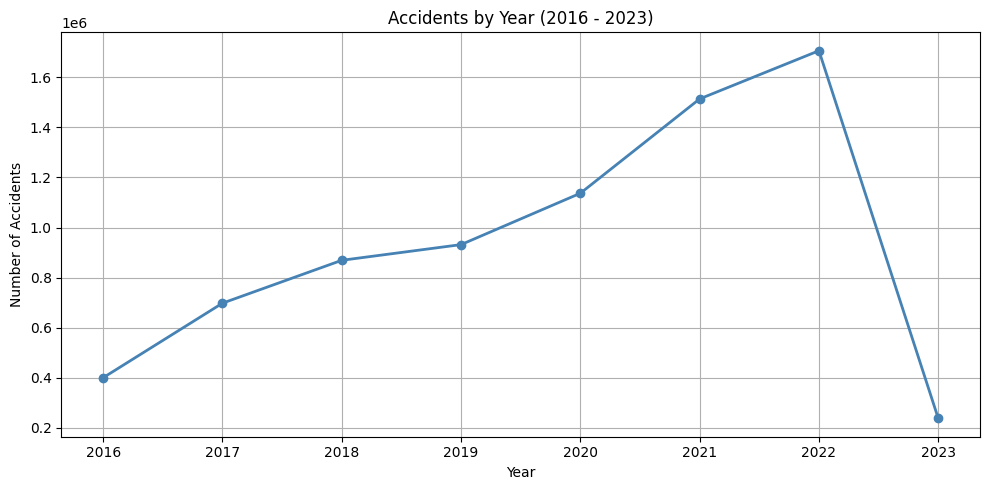

Chart 2 - Top 10 States


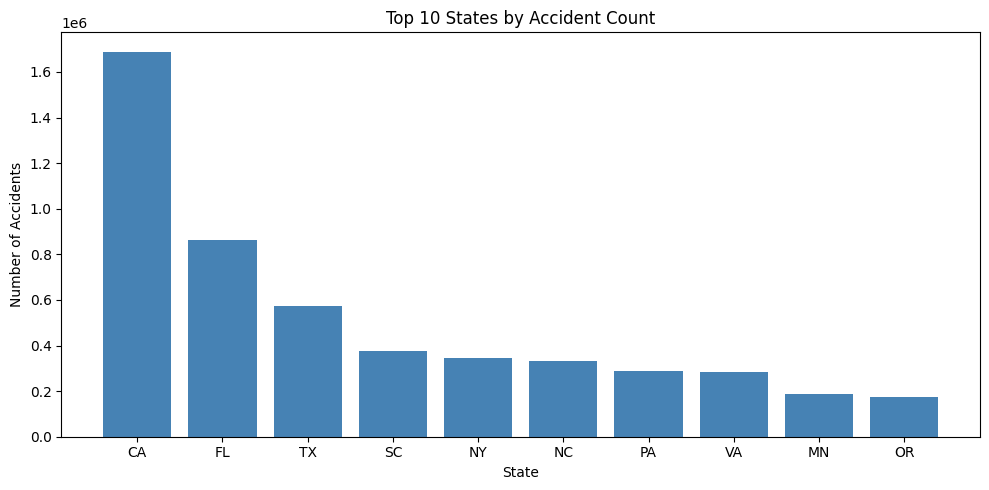

Chart 3 - Accidents by Hour


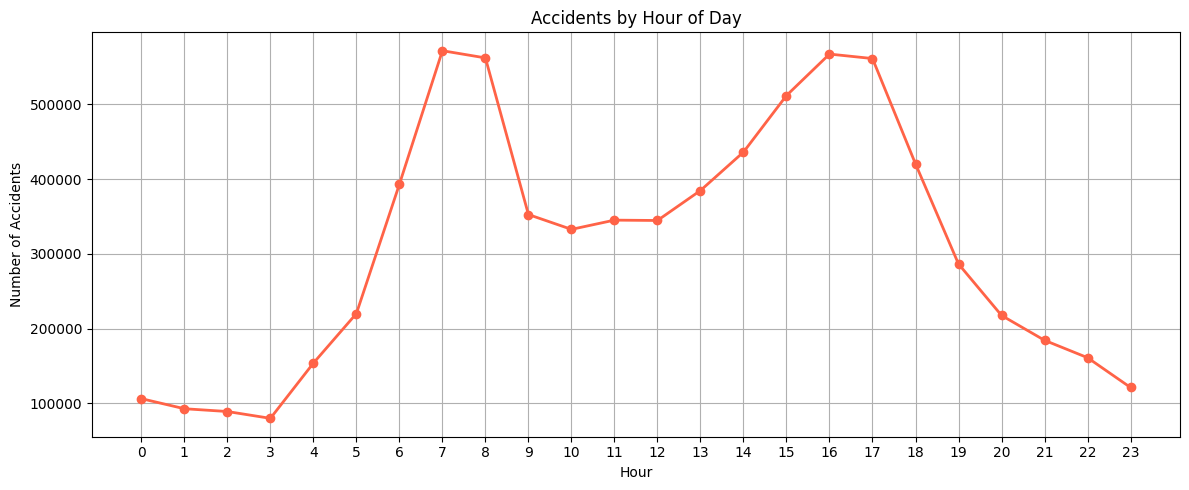

Chart 4 - Severity Distribution


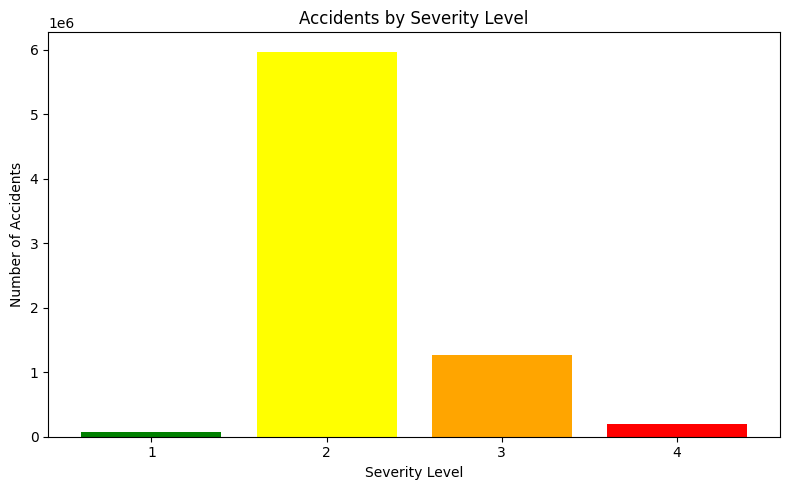


All 4 charts created and saved to: /Users/sanjaybharvad/us_accidents_project/charts/


In [15]:
# Creating and displaying main charts

import matplotlib.pyplot as plt
import pandas as pd
import os

output_dir = "/Users/sanjaybharvad/us_accidents_project/charts/"
os.makedirs(output_dir, exist_ok=True)

# Chart 1 - Accidents by Year
print("Chart 1 - Accidents by Year")
yearly_pd = df.groupBy("Year") \
    .agg(count("*").alias("Accident_Count")) \
    .orderBy("Year").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_pd["Year"], yearly_pd["Accident_Count"], marker="o", color="steelblue", linewidth=2)
ax.set_title("Accidents by Year (2016 - 2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Accidents")
ax.set_xticks(yearly_pd["Year"])
ax.grid(True)
plt.tight_layout()
plt.savefig(output_dir + "accidents_by_year.png")
plt.show()
plt.close()

# Chart 2 - Top 10 States
print("Chart 2 - Top 10 States")
states_pd = df.groupBy("State") \
    .agg(count("*").alias("Accident_Count")) \
    .orderBy(col("Accident_Count").desc()).limit(10).toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(states_pd["State"], states_pd["Accident_Count"], color="steelblue")
ax.set_title("Top 10 States by Accident Count")
ax.set_xlabel("State")
ax.set_ylabel("Number of Accidents")
plt.tight_layout()
plt.savefig(output_dir + "top_10_states.png")
plt.show()
plt.close()

# Chart 3 - Accidents by Hour
print("Chart 3 - Accidents by Hour")
hourly_pd = df.groupBy("Hour") \
    .agg(count("*").alias("Accident_Count")) \
    .orderBy("Hour").toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_pd["Hour"], hourly_pd["Accident_Count"], marker="o", color="tomato", linewidth=2)
ax.set_title("Accidents by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Accidents")
ax.set_xticks(range(0, 24))
ax.grid(True)
plt.tight_layout()
plt.savefig(output_dir + "accidents_by_hour.png")
plt.show()
plt.close()

# Chart 4 - Severity Distribution
print("Chart 4 - Severity Distribution")
severity_pd = df.groupBy("Severity") \
    .agg(count("*").alias("Count")) \
    .orderBy("Severity").toPandas()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(severity_pd["Severity"], severity_pd["Count"],
       color=["green", "yellow", "orange", "red"])
ax.set_title("Accidents by Severity Level")
ax.set_xlabel("Severity Level")
ax.set_ylabel("Number of Accidents")
ax.set_xticks([1, 2, 3, 4])
plt.tight_layout()
plt.savefig(output_dir + "severity_distribution.png")
plt.show()
plt.close()

print()
print("All 4 charts created and saved to:", output_dir)

In [16]:
import subprocess
import os

local_path = "/Users/sanjaybharvad/us_accidents_project/ml_ready_local/"
os.makedirs(local_path, exist_ok=True)

result = subprocess.run([
    "hdfs", "dfs", "-get",
    "/user/accidents/ml_ready/",
    local_path
], capture_output=True, text=True)

print("Export done!")
print(result.stderr)

Export done!
2026-05-07 18:33:01,912 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable



In [17]:
import os
path = "/Users/sanjaybharvad/us_accidents_project/ml_ready_local/ml_ready/"
files = os.listdir(path)
print("Files found:", len(files))
for f in files:
    print(f)

Files found: 24
part-00017-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00021-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00000-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00010-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00007-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00011-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00006-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00016-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00020-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00001-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00013-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00018-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00004-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00008-3756c4b2-5582-4280-ba30-6d1f9723eea4-c000.snappy.parquet
part-00014-3756c4b2-5582-4280-ba

In [18]:
import os

base = "/Users/sanjaybharvad/us_accidents_project/ml_ready_local/"
for root, dirs, files in os.walk(base):
    print(root)

/Users/sanjaybharvad/us_accidents_project/ml_ready_local/
/Users/sanjaybharvad/us_accidents_project/ml_ready_local/ml_ready


In [19]:
# ML Analysis - adding models to main notebook
# df is already loaded with 7.49M cleaned records

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator, BinaryClassificationEvaluator

# Convert boolean road columns to integer
road_features = [
    "Amenity", "Crossing", "Junction", "Stop",
    "Traffic_Signal", "Roundabout", "Bump", "Railway"
]
for c in road_features:
    df = df.withColumn(c, col(c).cast(IntegerType()))

numeric_features = [
    "Start_Lat", "Start_Lng", "Distance(mi)",
    "Temperature(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)",
    "Hour", "Month", "Year", "DayOfWeek",
    "Is_RushHour", "Is_Weekend"
]
all_features = numeric_features + road_features
df = df.fillna(0, subset=all_features)
df = df.fillna(0, subset=["Duration_Min"])

print("ML libraries imported")
print("Features ready:", len(all_features))

ML libraries imported
Features ready: 22


In [21]:
# Model 1 - Severity Prediction using Random Forest

import builtins

print("Model 1 - Severity Prediction")

severity_features = [f for f in all_features if f != "Is_RushHour"]

df_sev = df.withColumn("label", (col("Severity") - 1).cast(DoubleType()))
df_sev = df_sev.filter(col("label").between(0, 3))

train_sev, test_sev = df_sev.randomSplit([0.8, 0.2], seed=42)

assembler_sev = VectorAssembler(inputCols=severity_features, outputCol="features", handleInvalid="skip")
scaler_sev    = StandardScaler(inputCol="features", outputCol="scaled_features")
rf            = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="label",
    numTrees=30,
    maxDepth=8,
    seed=42
)

pipeline_sev = Pipeline(stages=[assembler_sev, scaler_sev, rf])

print("Training Random Forest model...")
model_sev = pipeline_sev.fit(train_sev)
print("Training complete")

predictions_sev = model_sev.transform(test_sev)

acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

accuracy_sev = acc_eval.evaluate(predictions_sev)
f1_sev       = f1_eval.evaluate(predictions_sev)

print()
print("Model 1 Results - Severity Prediction")
print("Accuracy :", builtins.round(accuracy_sev * 100, 2), "%")
print("F1 Score :", builtins.round(f1_sev, 4))

rf_model   = model_sev.stages[-1]
importance = list(zip(severity_features, rf_model.featureImportances.toArray()))
importance.sort(key=lambda x: x[1], reverse=True)

print()
print("Top 10 Important Features:")
for feat, imp in importance[:10]:
    print(f"  {feat:<25} {builtins.round(imp * 100, 2)}%")

print()
print("Sample Predictions:")
predictions_sev.select(
    (col("label") + 1).alias("Actual_Severity"),
    (col("prediction") + 1).alias("Predicted_Severity")
).show(10)

Model 1 - Severity Prediction
Training Random Forest model...


Training complete



Model 1 Results - Severity Prediction
Accuracy : 80.17 %
F1 Score : 0.7242

Top 10 Important Features:
  Distance(mi)              40.39%
  Year                      28.06%
  Traffic_Signal            9.03%
  Crossing                  5.61%
  Start_Lng                 3.07%
  Is_Weekend                2.35%
  Month                     2.11%
  Start_Lat                 1.95%
  Stop                      1.68%
  Wind_Speed(mph)           1.35%

Sample Predictions:


[Stage 281:>                                                        (0 + 1) / 1]

+---------------+------------------+
|Actual_Severity|Predicted_Severity|
+---------------+------------------+
|            2.0|               2.0|
|            2.0|               2.0|
|            3.0|               2.0|
|            2.0|               2.0|
|            2.0|               2.0|
|            2.0|               2.0|
|            2.0|               2.0|
|            2.0|               2.0|
|            3.0|               2.0|
|            3.0|               2.0|
+---------------+------------------+
only showing top 10 rows


In [23]:
# Model 2 - Duration Prediction using Linear Regression

import builtins

print("Model 2 - Duration Prediction")

df_dur = df.filter(
    (col("Duration_Min") > 0) &
    (col("Duration_Min") < 1440)
)
df_dur = df_dur.withColumn("label", col("Duration_Min").cast(DoubleType()))

train_dur, test_dur = df_dur.randomSplit([0.8, 0.2], seed=42)

assembler_dur = VectorAssembler(inputCols=all_features, outputCol="features", handleInvalid="skip")
scaler_dur    = StandardScaler(inputCol="features", outputCol="scaled_features")
lr            = LinearRegression(
    featuresCol="scaled_features",
    labelCol="label",
    maxIter=10,
    regParam=0.1
)

pipeline_dur = Pipeline(stages=[assembler_dur, scaler_dur, lr])

print("Training Linear Regression model...")
model_dur = pipeline_dur.fit(train_dur)
print("Training complete")

predictions_dur = model_dur.transform(test_dur)

rmse_eval = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
r2_eval   = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
mae_eval  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")

rmse = rmse_eval.evaluate(predictions_dur)
r2   = r2_eval.evaluate(predictions_dur)
mae  = mae_eval.evaluate(predictions_dur)

print()
print("Model 2 Results - Duration Prediction")
print("RMSE     :", builtins.round(rmse, 2), "minutes")
print("MAE      :", builtins.round(mae, 2), "minutes")
print("R2 Score :", builtins.round(r2, 4))

print()
print("Sample Predictions:")
predictions_dur.select(
    col("Duration_Min").alias("Actual_Duration_Min"),
    col("prediction").alias("Predicted_Duration_Min")
).show(10)

Model 2 - Duration Prediction
Training Linear Regression model...


Training complete



Model 2 Results - Duration Prediction
RMSE     : 121.23 minutes
MAE      : 74.12 minutes
R2 Score : 0.0379

Sample Predictions:


[Stage 318:>                                                        (0 + 1) / 1]

+-------------------+----------------------+
|Actual_Duration_Min|Predicted_Duration_Min|
+-------------------+----------------------+
|               30.0|     93.92785330327911|
|               60.0|    113.81193882482444|
|               60.0|    114.06243295217837|
|               60.0|     91.52057411616488|
|               60.0|     65.26999230446881|
|               60.0|     91.39508166450855|
|               60.0|     91.88585308382676|
|               60.0|      89.9105852596017|
|               60.0|     91.32329540140358|
|               60.0|     89.90941345798728|
+-------------------+----------------------+
only showing top 10 rows


In [24]:
# Model 3 - Rush Hour Prediction using Logistic Regression

import builtins

print("Model 3 - Rush Hour Prediction")

df_rush = df.withColumn("label", col("Is_RushHour").cast(DoubleType()))

rush_features = [
    "Start_Lat", "Start_Lng", "Distance(mi)",
    "Temperature(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)",
    "Hour", "Month", "DayOfWeek",
    "Amenity", "Crossing", "Junction", "Stop",
    "Traffic_Signal", "Roundabout"
]

train_rush, test_rush = df_rush.randomSplit([0.8, 0.2], seed=42)

assembler_rush = VectorAssembler(inputCols=rush_features, outputCol="features", handleInvalid="skip")
scaler_rush    = StandardScaler(inputCol="features", outputCol="scaled_features")
log_reg        = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="label",
    maxIter=10,
    regParam=0.01
)

pipeline_rush = Pipeline(stages=[assembler_rush, scaler_rush, log_reg])

print("Training Logistic Regression model...")
model_rush = pipeline_rush.fit(train_rush)
print("Training complete")

predictions_rush = model_rush.transform(test_rush)

acc_rush = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
auc_rush = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

accuracy_rush = acc_rush.evaluate(predictions_rush)
auc           = auc_rush.evaluate(predictions_rush)

print()
print("Model 3 Results - Rush Hour Prediction")
print("Accuracy :", builtins.round(accuracy_rush * 100, 2), "%")
print("AUC ROC  :", builtins.round(auc, 4))

print()
print("Prediction breakdown:")
predictions_rush.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

print()
print("Sample Predictions:")
predictions_rush.select(
    col("label").alias("Actual_RushHour"),
    col("prediction").alias("Predicted_RushHour")
).show(10)

Model 3 - Rush Hour Prediction
Training Logistic Regression model...


Training complete



Model 3 Results - Rush Hour Prediction
Accuracy : 59.43 %
AUC ROC  : 0.5521

Prediction breakdown:


+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  0.0|       0.0|888048|
|  0.0|       1.0|  3780|
|  1.0|       0.0|603666|
|  1.0|       1.0|  1854|
+-----+----------+------+


Sample Predictions:


[Stage 377:>                                                        (0 + 1) / 1]

+---------------+------------------+
|Actual_RushHour|Predicted_RushHour|
+---------------+------------------+
|            1.0|               0.0|
|            0.0|               0.0|
|            0.0|               0.0|
|            1.0|               0.0|
|            1.0|               0.0|
|            1.0|               0.0|
|            1.0|               0.0|
|            1.0|               0.0|
|            1.0|               0.0|
|            1.0|               0.0|
+---------------+------------------+
only showing top 10 rows


In [25]:
# Summary of all 3 ML models

import builtins

print("ML Models Summary - US Accidents Dataset")
print()
print("Dataset: 7.49M records processed using Spark MLlib on HDFS")
print()
print("Model 1 - Severity Prediction")
print("  Algorithm : Random Forest Classifier")
print("  Target    : Severity Level 1 2 3 4")
print("  Accuracy  :", builtins.round(accuracy_sev * 100, 2), "%")
print("  F1 Score  :", builtins.round(f1_sev, 4))
print()
print("Model 2 - Duration Prediction")
print("  Algorithm : Linear Regression")
print("  Target    : Accident Duration in Minutes")
print("  RMSE      :", builtins.round(rmse, 2), "minutes")
print("  MAE       :", builtins.round(mae, 2), "minutes")
print("  R2 Score  :", builtins.round(r2, 4))
print()
print("Model 3 - Rush Hour Prediction")
print("  Algorithm : Logistic Regression")
print("  Target    : Is Rush Hour 0 or 1")
print("  Accuracy  :", builtins.round(accuracy_rush * 100, 2), "%")
print("  AUC ROC   :", builtins.round(auc, 4))
print()
print("All models trained on 7.49M records using Spark MLlib on HDFS")

ML Models Summary - US Accidents Dataset

Dataset: 7.49M records processed using Spark MLlib on HDFS

Model 1 - Severity Prediction
  Algorithm : Random Forest Classifier
  Target    : Severity Level 1 2 3 4
  Accuracy  : 80.17 %
  F1 Score  : 0.7242

Model 2 - Duration Prediction
  Algorithm : Linear Regression
  Target    : Accident Duration in Minutes
  RMSE      : 121.23 minutes
  MAE       : 74.12 minutes
  R2 Score  : 0.0379

Model 3 - Rush Hour Prediction
  Algorithm : Logistic Regression
  Target    : Is Rush Hour 0 or 1
  Accuracy  : 59.43 %
  AUC ROC   : 0.5521

All models trained on 7.49M records using Spark MLlib on HDFS
